# Capítulo 27 — Reducción de dimensionalidad con PCA

En los dos cuadernos anteriores trabajamos con datos sin una variable objetivo y estudiamos K-Means en profundidad. Ahora abordaremos otra herramienta del aprendizaje no supervisado: **PCA**, o análisis de componentes principales.

Retomaremos explícitamente varios ejemplos del capítulo teórico. Comenzaremos con viviendas cuyas variables describen aspectos relacionados del tamaño, utilizaremos flores para visualizar clases conocidas y volveremos al conjunto de clientes de los Cuadernos 25 y 26 para representar clusters calculados en un espacio de cinco dimensiones.

PCA no elegirá algunas columnas y descartará las demás. Construirá nuevas dimensiones a partir de combinaciones de las variables originales. El objetivo será comprender qué conserva esa representación, qué deja afuera y qué precauciones exige su interpretación.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- reconocer cuándo varias variables contienen información relacionada;
- explicar por qué PCA es sensible a la escala;
- interpretar las componentes como nuevas direcciones de variación;
- distinguir entre coordenadas transformadas y pesos de las variables;
- consultar la varianza explicada y la varianza acumulada;
- elegir una cantidad de componentes según el propósito del análisis;
- analizar una reconstrucción aproximada de los datos;
- usar dos componentes para construir una visualización exploratoria;
- diferenciar entre usar PCA para graficar y usarlo antes de otro modelo;
- integrar escalado, PCA y un modelo dentro de un pipeline sin fuga de datos;
- comunicar las componentes y sus limitaciones con prudencia.


## 1. Importar las herramientas

Usaremos NumPy y Pandas para los cálculos y las tablas, Matplotlib para las visualizaciones y distintas herramientas de `scikit-learn` para escalar, reducir dimensiones, agrupar y evaluar un pequeño flujo supervisado.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 2. Recuperar el ejemplo de viviendas

El capítulo teórico propone variables como superficie, ambientes, dormitorios y baños para mostrar que columnas diferentes pueden expresar, en parte, una idea común de tamaño.

Construiremos un conjunto didáctico de viviendas. Los datos son sintéticos: permiten controlar las relaciones para estudiar PCA, pero no deben interpretarse como una muestra del mercado inmobiliario real.


In [2]:
generador = np.random.default_rng(27)
cantidad_viviendas = 180

tamano_general = generador.normal(0, 1, cantidad_viviendas)
calidad_general = generador.normal(0, 1, cantidad_viviendas)
antiguedad = generador.integers(0, 61, cantidad_viviendas)

superficie_cubierta = (
    88
    + 27 * tamano_general
    + 7 * calidad_general
    + generador.normal(0, 6, cantidad_viviendas)
)
superficie_total = (
    superficie_cubierta
    + 32
    + 12 * tamano_general
    + generador.normal(0, 9, cantidad_viviendas)
)
ambientes = (
    3.4
    + 1.05 * tamano_general
    + generador.normal(0, 0.45, cantidad_viviendas)
)
dormitorios = (
    2.2
    + 0.78 * tamano_general
    + generador.normal(0, 0.40, cantidad_viviendas)
)
banos = (
    1.45
    + 0.43 * tamano_general
    + 0.20 * calidad_general
    + generador.normal(0, 0.25, cantidad_viviendas)
)
expensas = (
    72_000
    + 22_000 * tamano_general
    + 15_000 * calidad_general
    - 250 * antiguedad
    + generador.normal(0, 8_000, cantidad_viviendas)
)

viviendas = pd.DataFrame({
    "superficie_cubierta": np.clip(superficie_cubierta, 28, None),
    "superficie_total": np.clip(superficie_total, 38, None),
    "ambientes": np.clip(np.rint(ambientes), 1, 7).astype(int),
    "dormitorios": np.clip(np.rint(dormitorios), 1, 6).astype(int),
    "banos": np.clip(np.rint(banos), 1, 4).astype(int),
    "antiguedad_anos": antiguedad,
    "expensas_mensuales": np.clip(expensas, 12_000, None),
})

viviendas[["superficie_cubierta", "superficie_total"]] = (
    viviendas[["superficie_cubierta", "superficie_total"]].round(1)
)
viviendas["expensas_mensuales"] = (
    viviendas["expensas_mensuales"].round(-2)
)

viviendas.head(8)


,superficie_cubierta,superficie_total,ambientes,dormitorios,banos,antiguedad_anos,expensas_mensuales
0,122.900,185.300,4,3,2,13,"80,400.000"
1,118.400,175.100,5,3,2,19,"98,800.000"
2,101.100,143.900,4,3,1,16,"78,000.000"
3,69.600,81.600,2,2,1,37,"42,900.000"
4,115.200,154.800,4,3,2,22,"83,900.000"
5,93.900,139.700,3,2,2,32,"104,000.000"
6,101.600,117.800,3,2,2,44,"71,200.000"
7,125.300,156.100,5,3,2,27,"100,100.000"


In [3]:
resumen_viviendas = viviendas.agg(["mean", "std", "min", "max"]).T
resumen_viviendas.columns = ["media", "desviacion", "minimo", "maximo"]

print("Dimensiones del conjunto:", viviendas.shape)
resumen_viviendas


Dimensiones del conjunto: (180, 7)


,media,desviacion,minimo,maximo
superficie_cubierta,87.441,27.962,28.000,152.300
superficie_total,120.578,39.264,38.000,213.500
ambientes,3.378,1.089,1.000,6.000
dormitorios,2.250,0.858,1.000,5.000
banos,1.489,0.534,1.000,3.000
antiguedad_anos,32.294,16.449,0.000,60.000
expensas_mensuales,"64,697.222","26,565.680","12,000.000","127,700.000"


Las columnas no comparten unidades ni escalas. Algunas son superficies en metros cuadrados, otras son cantidades, la antigüedad se expresa en años y las expensas en pesos. Antes de reducir dimensiones conviene observar cómo se relacionan.


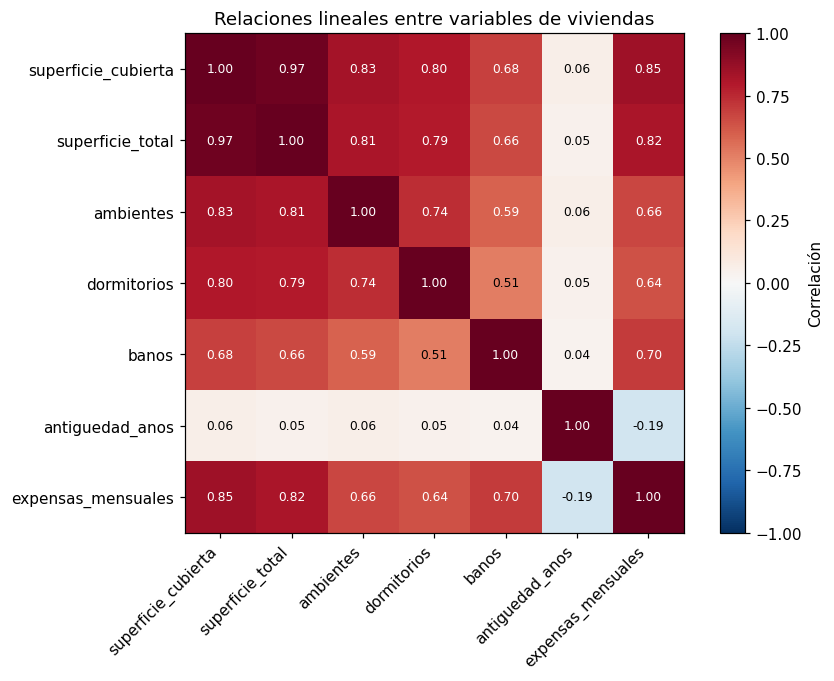

In [4]:
correlaciones = viviendas.corr()

fig, ax = plt.subplots(figsize=(8.2, 6.3))
imagen = ax.imshow(correlaciones, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(correlaciones.columns)))
ax.set_yticks(range(len(correlaciones.columns)))
ax.set_xticklabels(correlaciones.columns, rotation=45, ha="right")
ax.set_yticklabels(correlaciones.columns)

for fila in range(len(correlaciones)):
    for columna in range(len(correlaciones)):
        valor = correlaciones.iloc[fila, columna]
        color = "white" if abs(valor) > 0.55 else "black"
        ax.text(
            columna,
            fila,
            f"{valor:.2f}",
            ha="center",
            va="center",
            color=color,
            fontsize=8,
        )

fig.colorbar(imagen, ax=ax, label="Correlación")
ax.set_title("Relaciones lineales entre variables de viviendas")
plt.tight_layout()
plt.show()


Las variables asociadas al tamaño se mueven juntas con bastante claridad. La antigüedad, en cambio, describe otro aspecto del conjunto. Esta estructura sugiere que parte de la información podría resumirse en menos direcciones.

La correlación no demuestra causalidad ni vuelve innecesarias a las columnas. Solo muestra relaciones lineales que PCA puede aprovechar.


## 3. Comprobar por qué importa el escalado

PCA busca direcciones con mucha varianza. Si usamos las unidades originales, `expensas_mensuales` presenta números muy superiores a los de `baños` o `ambientes`. Esa diferencia puede hacer que una sola columna domine el resultado.

Compararemos la primera componente calculada sin escalar con la obtenida después de aplicar `StandardScaler`. Para facilitar la lectura, mostraremos el peso absoluto de cada variable: cuanto mayor sea, mayor será su participación en esa componente.


In [5]:
X_viviendas = viviendas.copy()

pca_sin_escalar = PCA()
pca_sin_escalar.fit(X_viviendas)

escalador_viviendas = StandardScaler()
X_viviendas_escalado = escalador_viviendas.fit_transform(X_viviendas)

pca_escalado = PCA()
pca_escalado.fit(X_viviendas_escalado)

comparacion_pesos = pd.DataFrame({
    "variable": X_viviendas.columns,
    "peso_abs_PC1_sin_escalar": np.abs(
        pca_sin_escalar.components_[0]
    ),
    "peso_abs_PC1_escalado": np.abs(
        pca_escalado.components_[0]
    ),
}).sort_values("peso_abs_PC1_sin_escalar", ascending=False)

comparacion_pesos


,variable,peso_abs_PC1_sin_escalar,peso_abs_PC1_escalado
6,expensas_mensuales,1.000,0.405
1,superficie_total,0.001,0.442
0,superficie_cubierta,0.001,0.448
5,antiguedad_anos,0.000,0.006
2,ambientes,0.000,0.403
3,dormitorios,0.000,0.389
4,banos,0.000,0.356


Sin escalado, los pesos reflejan principalmente las unidades y la dispersión numérica. Después de estandarizar, las variables vinculadas al tamaño pueden participar de manera más equilibrada.

Escalar no significa afirmar que todas las variables tienen la misma importancia conceptual. Significa evitar que una unidad grande decida por sí sola las direcciones de PCA.


## 4. Ver las componentes como nuevos ejes

Para observar la geometría usaremos solo `superficie_cubierta` y `ambientes`, dos variables relacionadas del ejemplo teórico. Una vez estandarizadas, PCA encontrará dos direcciones perpendiculares.

La primera seguirá aproximadamente la forma alargada de la nube. La segunda describirá variaciones que no quedaron capturadas por la primera.


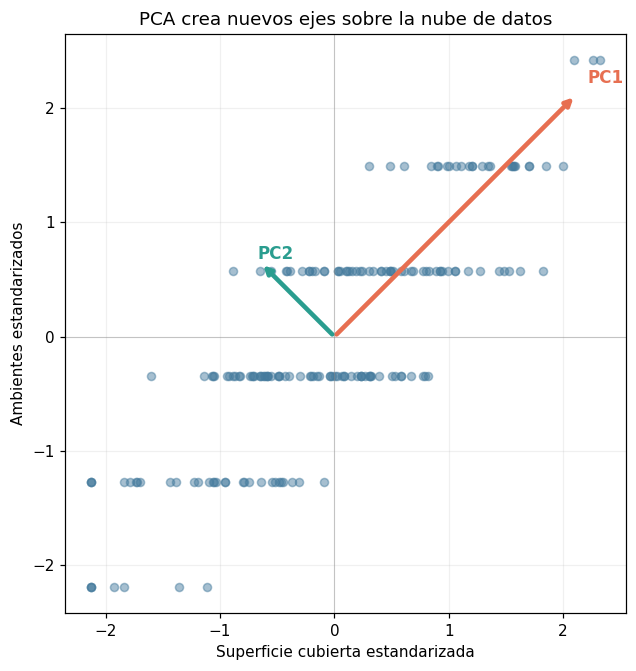

In [6]:
variables_geometria = ["superficie_cubierta", "ambientes"]
X_geometria = StandardScaler().fit_transform(
    viviendas[variables_geometria]
)

pca_geometria = PCA(n_components=2)
coordenadas_geometria = pca_geometria.fit_transform(X_geometria)

fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.scatter(
    X_geometria[:, 0],
    X_geometria[:, 1],
    alpha=0.48,
    color="#457B9D",
    s=28,
)

colores_ejes = ["#E76F51", "#2A9D8F"]
for indice, (direccion, varianza) in enumerate(zip(
    pca_geometria.components_,
    pca_geometria.explained_variance_,
)):
    longitud = 2.2 * np.sqrt(varianza)
    extremo = direccion * longitud
    ax.annotate(
        "",
        xy=extremo,
        xytext=(0, 0),
        arrowprops={
            "arrowstyle": "->",
            "lw": 3,
            "color": colores_ejes[indice],
        },
    )
    ax.text(
        extremo[0] * 1.05,
        extremo[1] * 1.05,
        f"PC{indice + 1}",
        color=colores_ejes[indice],
        fontsize=11,
        weight="bold",
    )

ax.axhline(0, color="gray", lw=0.7, alpha=0.4)
ax.axvline(0, color="gray", lw=0.7, alpha=0.4)
ax.set_xlabel("Superficie cubierta estandarizada")
ax.set_ylabel("Ambientes estandarizados")
ax.set_title("PCA crea nuevos ejes sobre la nube de datos")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()


Los ejes principales no son columnas elegidas del dataset. Cada dirección combina las dos variables originales. La primera concentra la variación compartida; la segunda conserva una parte menor y perpendicular.

El sentido de una flecha puede aparecer invertido en otra ejecución o implementación sin cambiar el resultado. Multiplicar una componente y sus coordenadas por `-1` describe el mismo eje geométrico.


In [7]:
pesos_geometria = pd.DataFrame(
    pca_geometria.components_,
    index=["PC1", "PC2"],
    columns=variables_geometria,
)

varianza_geometria = pd.DataFrame({
    "componente": ["PC1", "PC2"],
    "proporcion_varianza": (
        pca_geometria.explained_variance_ratio_
    ),
    "varianza_acumulada": np.cumsum(
        pca_geometria.explained_variance_ratio_
    ),
})

print("Pesos de las variables en cada componente:")
print(pesos_geometria.to_string())

print("Varianza explicada:")
varianza_geometria


Pesos de las variables en cada componente:
     superficie_cubierta  ambientes
PC1                0.707      0.707
PC2               -0.707      0.707
Varianza explicada:


,componente,proporcion_varianza,varianza_acumulada
0,PC1,0.915,0.915
1,PC2,0.085,1.000


Los **pesos** indican cómo se construye cada eje. Las **coordenadas** obtenidas con `transform`, en cambio, indican dónde queda ubicada cada vivienda sobre esos ejes. No son el mismo objeto.

En este ejemplo bidimensional, `PC1` explica aproximadamente el **91,5%** de la variación. La superficie y los ambientes tienen pesos casi iguales en esa dirección, lo que coincide con la idea de resumir una tendencia común de tamaño.


## 5. Aplicar PCA a todas las variables de viviendas

Volveremos ahora a las siete columnas. Primero ajustaremos el escalador y luego PCA. Conservaremos inicialmente todas las componentes para poder estudiar cuánto aporta cada una.


In [8]:
escalador_completo = StandardScaler()
X_escalado = escalador_completo.fit_transform(X_viviendas)

pca_completo = PCA()
X_componentes = pca_completo.fit_transform(X_escalado)

nombres_componentes = [
    f"PC{numero}"
    for numero in range(1, X_componentes.shape[1] + 1)
]

datos_componentes = pd.DataFrame(
    X_componentes,
    columns=nombres_componentes,
)

print("Forma original:", X_viviendas.shape)
print("Forma transformada:", datos_componentes.shape)
datos_componentes.head()


Forma original: (180, 7)
Forma transformada: (180, 7)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,2.445,-1.055,-0.111,-0.023,0.155,-0.983,-0.097
1,2.913,-0.818,-0.094,-0.160,-0.416,-0.020,-0.208
2,0.924,-0.919,-1.410,0.267,-0.050,0.093,-0.060
3,-2.010,0.295,-0.257,0.255,0.607,0.015,0.270
4,2.035,-0.602,0.096,-0.163,0.253,-0.272,0.129


Cada fila sigue representando una vivienda. Las columnas ya no son superficie, ambientes o antigüedad, sino nuevas coordenadas. Como conservamos las siete componentes, todavía no redujimos dimensiones; solo cambiamos el sistema de representación.

Para interpretar las primeras componentes, revisaremos los pesos de las variables originales.


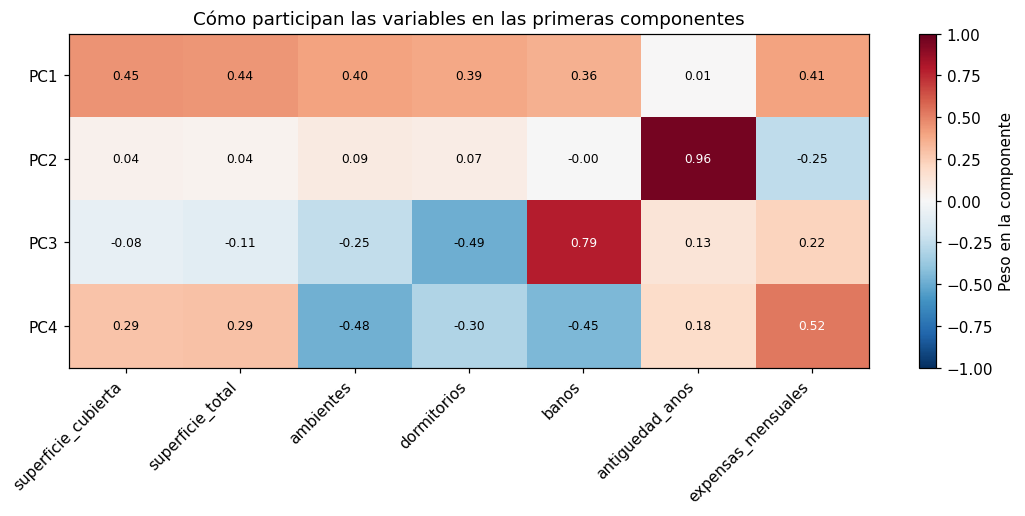

In [9]:
pesos_componentes = pd.DataFrame(
    pca_completo.components_[:4],
    index=["PC1", "PC2", "PC3", "PC4"],
    columns=X_viviendas.columns,
)

fig, ax = plt.subplots(figsize=(10, 4.8))
imagen = ax.imshow(
    pesos_componentes,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    aspect="auto",
)

ax.set_xticks(range(len(pesos_componentes.columns)))
ax.set_xticklabels(
    pesos_componentes.columns,
    rotation=45,
    ha="right",
)
ax.set_yticks(range(len(pesos_componentes.index)))
ax.set_yticklabels(pesos_componentes.index)

for fila in range(pesos_componentes.shape[0]):
    for columna in range(pesos_componentes.shape[1]):
        valor = pesos_componentes.iloc[fila, columna]
        color = "white" if abs(valor) > 0.52 else "black"
        ax.text(
            columna,
            fila,
            f"{valor:.2f}",
            ha="center",
            va="center",
            color=color,
            fontsize=8,
        )

fig.colorbar(imagen, ax=ax, label="Peso en la componente")
ax.set_title("Cómo participan las variables en las primeras componentes")
plt.tight_layout()
plt.show()


Cuando varias variables de tamaño presentan pesos importantes y con el mismo sentido en `PC1`, podemos proponer que esa componente está asociada con una dimensión general de tamaño o magnitud de la vivienda.

Esa etiqueta es una interpretación apoyada en los pesos, no un nombre producido por PCA. Otras componentes pueden mezclar variables de una manera menos sencilla y quizá sea más honesto describir sus aportes sin forzar un título.

En este conjunto, `PC1` reúne principalmente superficie, ambientes, dormitorios, baños y expensas. `PC2` queda dominada por la antigüedad. La primera explica aproximadamente el **67,3%** de la varianza y las dos primeras acumulan cerca del **82,5%**.


## 6. Medir la varianza explicada

Las componentes aparecen ordenadas. `PC1` conserva la mayor proporción posible de variación, `PC2` agrega otra parte y así sucesivamente.

Observaremos simultáneamente la contribución individual y la varianza acumulada. La línea horizontal del 90% es una referencia, no una regla universal.


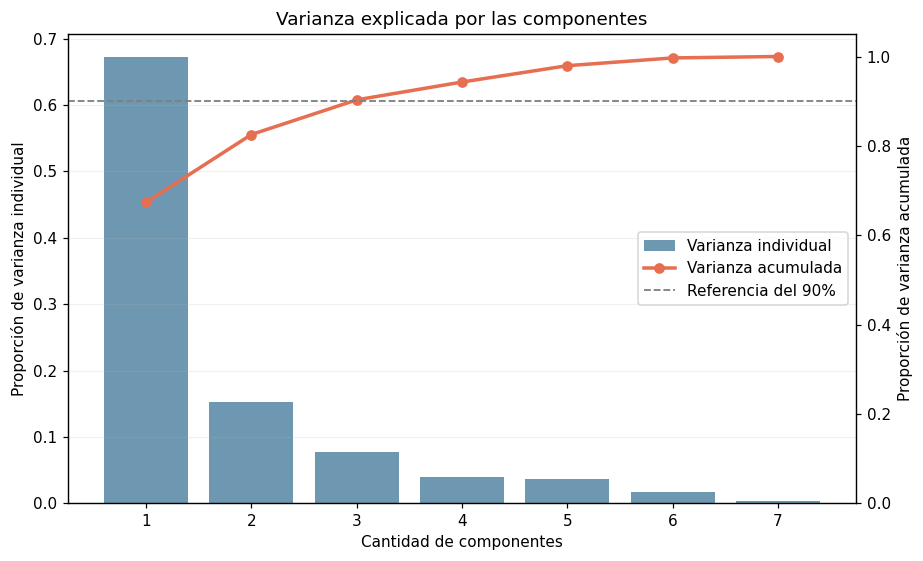

In [10]:
proporcion_varianza = pca_completo.explained_variance_ratio_
varianza_acumulada = np.cumsum(proporcion_varianza)
numero_componentes = np.arange(1, len(proporcion_varianza) + 1)

fig, ax1 = plt.subplots(figsize=(8.5, 5.2))
ax1.bar(
    numero_componentes,
    proporcion_varianza,
    color="#457B9D",
    alpha=0.78,
    label="Varianza individual",
)
ax1.set_xlabel("Cantidad de componentes")
ax1.set_ylabel("Proporción de varianza individual")
ax1.set_xticks(numero_componentes)

ax2 = ax1.twinx()
ax2.plot(
    numero_componentes,
    varianza_acumulada,
    color="#E76F51",
    marker="o",
    linewidth=2.3,
    label="Varianza acumulada",
)
ax2.axhline(
    0.90,
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label="Referencia del 90%",
)
ax2.set_ylabel("Proporción de varianza acumulada")
ax2.set_ylim(0, 1.05)

lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax2.legend(
    lineas1 + lineas2,
    etiquetas1 + etiquetas2,
    loc="center right",
)

ax1.set_title("Varianza explicada por las componentes")
ax1.grid(axis="y", alpha=0.18)
plt.tight_layout()
plt.show()


Si la curva acumulada sube con rapidez, pocas componentes resumen una parte grande de la variación. Si sube lentamente, la información está más distribuida.

Para visualizar solemos elegir dos componentes porque necesitamos un plano, aun cuando no alcancen un umbral alto. Para comprimir o preparar datos para otro modelo podemos conservar más.


In [11]:
pca_90 = PCA(n_components=0.90)
X_reducido_90 = pca_90.fit_transform(X_escalado)

tabla_varianza = pd.DataFrame({
    "componente": nombres_componentes,
    "varianza_individual": proporcion_varianza,
    "varianza_acumulada": varianza_acumulada,
})

print(
    "Componentes necesarias para alcanzar al menos el 90%:",
    pca_90.n_components_,
)
print(
    "Varianza conservada:",
    f"{pca_90.explained_variance_ratio_.sum():.2%}",
)
tabla_varianza


Componentes necesarias para alcanzar al menos el 90%: 3
Varianza conservada: 90.29%


,componente,varianza_individual,varianza_acumulada
0,PC1,0.673,0.673
1,PC2,0.152,0.825
2,PC3,0.078,0.903
3,PC4,0.040,0.943
4,PC5,0.037,0.979
5,PC6,0.017,0.997
6,PC7,0.003,1.000


`PCA(n_components=0.90)` elige automáticamente la cantidad mínima de componentes que alcanza el umbral. El resultado sigue dependiendo de las variables incluidas y del escalado aplicado.

Conservar el 90% de la varianza no garantiza conservar el 90% de lo relevante para cualquier pregunta. PCA resume `X`; no conoce objetivos, significados ni consecuencias.

En el ejemplo de viviendas son necesarias **tres componentes**, que conservan aproximadamente el **90,29%** de la varianza. Pasamos así de siete columnas originales a tres coordenadas, sin afirmar que el resumen sea suficiente para cualquier uso.


In [12]:
X_reconstruido_escalado = pca_90.inverse_transform(X_reducido_90)
X_reconstruido = escalador_completo.inverse_transform(
    X_reconstruido_escalado
)

reconstruccion = pd.DataFrame(
    X_reconstruido,
    columns=X_viviendas.columns,
)

mae_reconstruccion = (
    X_viviendas.subtract(reconstruccion)
    .abs()
    .mean()
)
desviacion_original = X_viviendas.std(ddof=0)

tabla_reconstruccion = pd.DataFrame({
    "MAE_reconstruccion": mae_reconstruccion,
    "desviacion_original": desviacion_original,
    "MAE_sobre_desviacion": (
        mae_reconstruccion / desviacion_original
    ),
})

tabla_reconstruccion


,MAE_reconstruccion,desviacion_original,MAE_sobre_desviacion
superficie_cubierta,4.934,27.884,0.177
superficie_total,8.505,39.154,0.217
ambientes,0.398,1.086,0.366
dormitorios,0.267,0.856,0.313
banos,0.110,0.532,0.206
antiguedad_anos,1.485,16.403,0.091
expensas_mensuales,"7,695.655","26,491.784",0.290


La transformación inversa produce una **aproximación**, no recupera necesariamente cada valor exacto. El error relativo a la desviación de cada columna ayuda a comparar variables con unidades distintas.

Al conservar menos componentes, la reconstrucción suele perder más detalle. Esa pérdida es el costo de representar las filas con menos coordenadas.


## 7. Visualizar flores con cuatro mediciones

El capítulo teórico menciona flores clasificadas por especie. Usaremos Iris, que contiene cuatro mediciones por flor. PCA recibirá únicamente `X`; las especies conocidas se usarán después para colorear el gráfico.

Por lo tanto, PCA no está clasificando ni aprendiendo con las etiquetas. El color es una ayuda interpretativa agregada una vez construida la proyección.


In [13]:
iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

escalador_iris = StandardScaler()
X_iris_escalado = escalador_iris.fit_transform(X_iris)

pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris_escalado)

print("Forma original:", X_iris.shape)
print("Forma reducida:", X_iris_pca.shape)
print(
    "Varianza explicada por las dos componentes:",
    f"{pca_iris.explained_variance_ratio_.sum():.2%}",
)


Forma original: (150, 4)
Forma reducida: (150, 2)
Varianza explicada por las dos componentes: 95.81%


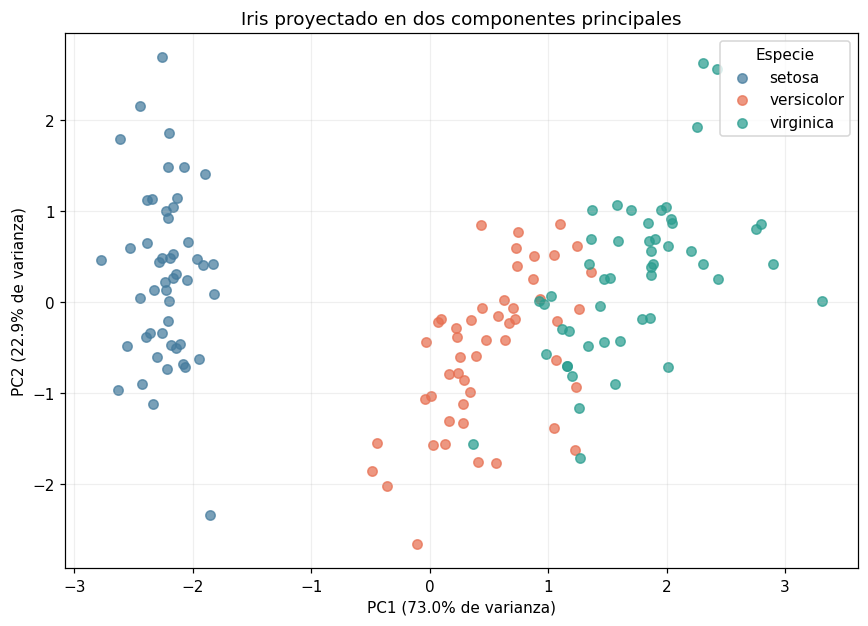

In [14]:
colores_iris = ["#457B9D", "#E76F51", "#2A9D8F"]

fig, ax = plt.subplots(figsize=(8, 5.8))

for clase, nombre, color in zip(
    range(3),
    iris.target_names,
    colores_iris,
):
    mascara = y_iris == clase
    ax.scatter(
        X_iris_pca[mascara, 0],
        X_iris_pca[mascara, 1],
        label=nombre,
        color=color,
        alpha=0.72,
        s=38,
    )

ax.set_xlabel(
    "PC1 "
    f"({pca_iris.explained_variance_ratio_[0]:.1%} de varianza)"
)
ax.set_ylabel(
    "PC2 "
    f"({pca_iris.explained_variance_ratio_[1]:.1%} de varianza)"
)
ax.set_title("Iris proyectado en dos componentes principales")
ax.legend(title="Especie")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


La representación permite observar una separación clara para una especie y cierta superposición entre las otras dos. La formulación responsable es: **en estas dos componentes se observa esa estructura**.

El gráfico no demuestra que las clases estén separadas perfectamente en el espacio original ni reemplaza la evaluación de un clasificador.

En este caso, las dos componentes explican en conjunto aproximadamente el **95,81%** de la varianza de las cuatro mediciones, por lo que el plano conserva una parte muy grande de la estructura general.


## 8. Usar PCA para visualizar los clusters del Cuaderno 26

Retomaremos el conjunto didáctico de clientes. K-Means formará tres grupos usando las cinco variables de comportamiento estandarizadas. Solo después aplicaremos PCA sobre ese mismo espacio para representarlo en dos dimensiones.

Esta secuencia importa: los clusters se calculan en cinco dimensiones; PCA se utiliza únicamente para graficarlos.


In [15]:
generador_clientes = np.random.default_rng(25)


def crear_clientes(
    cantidad,
    frecuencia_media,
    gasto_medio,
    recencia_media,
    antiguedad_media,
    categorias_media,
):
    return pd.DataFrame({
        "frecuencia_compra": generador_clientes.normal(
            frecuencia_media, 1.8, cantidad
        ),
        "gasto_promedio": generador_clientes.normal(
            gasto_medio, gasto_medio * 0.13, cantidad
        ),
        "dias_ultima_compra": generador_clientes.normal(
            recencia_media, max(4, recencia_media * 0.22), cantidad
        ),
        "antiguedad_meses": generador_clientes.normal(
            antiguedad_media, 8, cantidad
        ),
        "categorias_compradas": generador_clientes.normal(
            categorias_media, 0.8, cantidad
        ),
    })


clientes = pd.concat([
    crear_clientes(45, 14, 95_000, 9, 32, 5.5),
    crear_clientes(40, 5, 180_000, 28, 20, 3.5),
    crear_clientes(35, 2.5, 52_000, 88, 55, 2.2),
], ignore_index=True)

clientes["frecuencia_compra"] = (
    clientes["frecuencia_compra"].clip(0.5)
)
clientes["gasto_promedio"] = (
    clientes["gasto_promedio"].clip(10_000)
)
clientes["dias_ultima_compra"] = (
    clientes["dias_ultima_compra"].clip(1)
)
clientes["antiguedad_meses"] = (
    clientes["antiguedad_meses"].clip(1)
)
clientes["categorias_compradas"] = (
    clientes["categorias_compradas"].clip(1, 8)
)

clientes = (
    clientes
    .sample(frac=1, random_state=25)
    .reset_index(drop=True)
)

clientes.head()


,frecuencia_compra,gasto_promedio,dias_ultima_compra,antiguedad_meses,categorias_compradas
0,14.135,"82,362.982",9.639,19.295,6.126
1,13.629,"66,563.819",1.000,23.360,5.850
2,6.112,"172,448.372",35.395,26.773,3.693
3,14.216,"111,871.907",7.957,26.409,4.692
4,14.463,"107,989.800",1.964,24.354,4.660


In [16]:
escalador_clientes = StandardScaler()
X_clientes_escalado = escalador_clientes.fit_transform(clientes)

kmeans_clientes = KMeans(
    n_clusters=3,
    random_state=26,
    n_init=20,
)
clusters_clientes = kmeans_clientes.fit_predict(
    X_clientes_escalado
)

pca_clientes = PCA(n_components=2)
X_clientes_pca = pca_clientes.fit_transform(
    X_clientes_escalado
)

print("Espacio usado por K-Means:", X_clientes_escalado.shape)
print("Espacio usado para el gráfico:", X_clientes_pca.shape)
print(
    "Varianza visible en el gráfico:",
    f"{pca_clientes.explained_variance_ratio_.sum():.2%}",
)


Espacio usado por K-Means: (120, 5)
Espacio usado para el gráfico: (120, 2)
Varianza visible en el gráfico: 90.25%


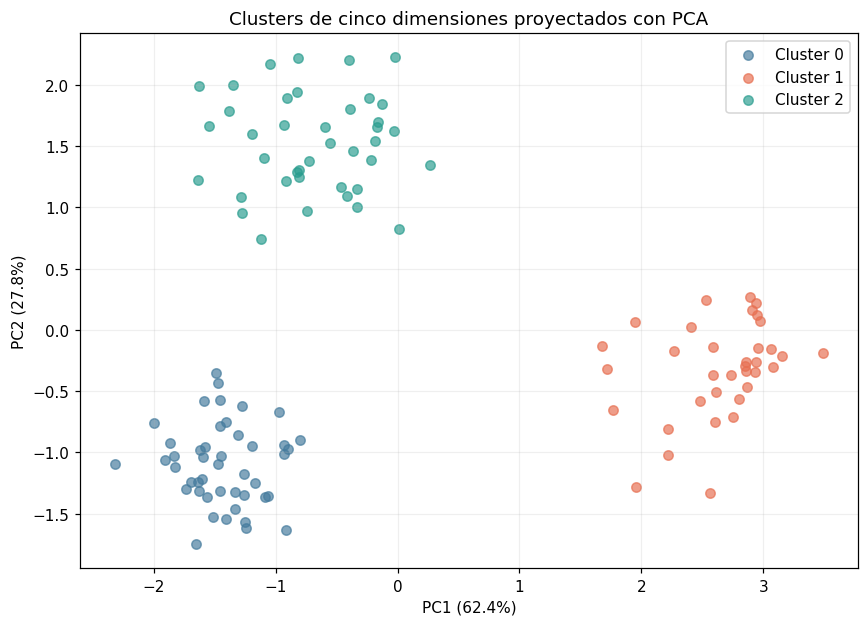

In [17]:
colores_clusters = ["#457B9D", "#E76F51", "#2A9D8F"]

fig, ax = plt.subplots(figsize=(8, 5.8))

for cluster, color in enumerate(colores_clusters):
    mascara = clusters_clientes == cluster
    ax.scatter(
        X_clientes_pca[mascara, 0],
        X_clientes_pca[mascara, 1],
        label=f"Cluster {cluster}",
        color=color,
        alpha=0.68,
        s=38,
    )

ax.set_xlabel(
    "PC1 "
    f"({pca_clientes.explained_variance_ratio_[0]:.1%})"
)
ax.set_ylabel(
    "PC2 "
    f"({pca_clientes.explained_variance_ratio_[1]:.1%})"
)
ax.set_title("Clusters de cinco dimensiones proyectados con PCA")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


El gráfico facilita la comunicación de una estructura que se calculó con cinco variables. Sin embargo, sigue siendo una proyección. Dos puntos o clusters que parecen cercanos aquí podrían diferenciarse en componentes no mostradas.

Un análisis distinto sería aplicar primero PCA y luego K-Means. En ese caso, los grupos se construirían sobre el resumen reducido y podrían cambiar. Siempre conviene documentar qué transformación se utilizó y en qué orden.

Las dos componentes visibles explican aproximadamente el **90,25%** de la varianza de este conjunto didáctico. Esa proporción ayuda a contextualizar por qué los tres grupos se observan con bastante claridad en el plano.


## 9. Integrar PCA en un flujo supervisado

PCA también puede utilizarse antes de un modelo. Para comprobar que mucha varianza no equivale automáticamente a mejor predicción, compararemos regresión logística con y sin PCA sobre Breast Cancer Wisconsin.

Reservaremos el test antes de cualquier comparación. El escalado y PCA quedarán dentro de cada pipeline y se ajustarán nuevamente dentro de cada fold de validación cruzada. La clase positiva será `1 = maligno`.


In [18]:
cancer = load_breast_cancer(as_frame=True)
X_cancer = cancer.data
y_cancer = 1 - cancer.target

X_desarrollo, X_test, y_desarrollo, y_test = train_test_split(
    X_cancer,
    y_cancer,
    test_size=0.25,
    stratify=y_cancer,
    random_state=27,
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=27,
)

configuraciones = {
    "Sin PCA": "passthrough",
    "PCA con 2 componentes": PCA(n_components=2),
    "PCA con 90% de varianza": PCA(n_components=0.90),
    "PCA con 95% de varianza": PCA(n_components=0.95),
}

print("Desarrollo:", X_desarrollo.shape)
print("Test reservado:", X_test.shape)


Desarrollo: (426, 30)
Test reservado: (143, 30)


In [19]:
filas_resultados = []
pipelines_cancer = {}

for nombre, paso_pca in configuraciones.items():
    pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("pca", paso_pca),
        ("modelo", LogisticRegression(max_iter=3000)),
    ])

    resultados = cross_validate(
        pipeline,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring="f1",
        n_jobs=None,
    )

    pipeline_ajustado = clone(pipeline).fit(
        X_desarrollo,
        y_desarrollo,
    )
    paso_ajustado = pipeline_ajustado.named_steps["pca"]

    if paso_ajustado == "passthrough":
        componentes_usadas = X_desarrollo.shape[1]
        varianza_conservada = 1.0
    else:
        componentes_usadas = paso_ajustado.n_components_
        varianza_conservada = (
            paso_ajustado.explained_variance_ratio_.sum()
        )

    filas_resultados.append({
        "configuracion": nombre,
        "componentes": componentes_usadas,
        "varianza_conservada": varianza_conservada,
        "F1_validacion_media": resultados["test_score"].mean(),
        "F1_validacion_desviacion": resultados["test_score"].std(),
    })
    pipelines_cancer[nombre] = pipeline

comparacion_modelos = (
    pd.DataFrame(filas_resultados)
    .sort_values("F1_validacion_media", ascending=False)
    .reset_index(drop=True)
)

comparacion_modelos


,configuracion,componentes,varianza_conservada,F1_validacion_media,F1_validacion_desviacion
0,PCA con 95% de varianza,10,0.953,0.974,0.008
1,Sin PCA,30,1.000,0.971,0.012
2,PCA con 90% de varianza,7,0.912,0.969,0.024
3,PCA con 2 componentes,2,0.641,0.945,0.034


La tabla permite separar dos preguntas:

- ¿cuánto se redujo la representación?;
- ¿cómo rindió el pipeline completo en los mismos folds?

Una configuración puede usar menos columnas transformadas sin mejorar el F1. PCA es una opción que debe evaluarse, no un paso obligatorio.

Aquí, PCA con un umbral del **95%** conserva diez componentes y obtiene un F1 medio de validación cercano a `0,974`. El pipeline sin PCA utiliza las treinta variables y queda muy próximo, alrededor de `0,971`. La pequeña diferencia no permite convertir PCA en una regla general.


In [20]:
nombre_elegido = comparacion_modelos.loc[0, "configuracion"]
pipeline_elegido = clone(
    pipelines_cancer[nombre_elegido]
)
pipeline_elegido.fit(X_desarrollo, y_desarrollo)

predicciones_test = pipeline_elegido.predict(X_test)

metricas_test = pd.DataFrame({
    "configuracion_elegida": [nombre_elegido],
    "accuracy_test": [
        accuracy_score(y_test, predicciones_test)
    ],
    "F1_test": [
        f1_score(y_test, predicciones_test)
    ],
})

matriz_test = pd.DataFrame(
    confusion_matrix(y_test, predicciones_test),
    index=["Real benigno", "Real maligno"],
    columns=["Predicho benigno", "Predicho maligno"],
)

print(metricas_test.to_string(index=False))
matriz_test


  configuracion_elegida  accuracy_test  F1_test
PCA con 95% de varianza          0.958    0.943


,Predicho benigno,Predicho maligno
Real benigno,87,3
Real maligno,3,50


El test se consultó una sola vez, después de elegir la configuración mediante validación cruzada sobre desarrollo. Esta evaluación no demuestra que una decisión sea universalmente superior; describe lo ocurrido en este conjunto y con este flujo.

El punto central es metodológico: si PCA participa en un problema supervisado, debe aprenderse dentro del pipeline para evitar que la validación o el test influyan en la transformación.

La configuración elegida alcanza accuracy `0,958` y F1 `0,943` en el test reservado. Comete tres falsas alarmas y deja sin detectar tres casos malignos. Estas cifras sirven para cerrar el ejemplo, no para afirmar que reducir a diez componentes será siempre mejor.


## 10. Actividad modificable

El siguiente bloque permite cambiar el umbral de varianza conservada en el ejemplo de viviendas. Probá valores como `0.75`, `0.85`, `0.90`, `0.95` o `0.99`.

Observá simultáneamente cuántas componentes se conservan y cuánto cambia el error medio de reconstrucción en datos estandarizados.


In [21]:
umbral = 0.90  # Modificá este valor entre 0 y 1.

pca_actividad = PCA(n_components=umbral)
X_actividad = pca_actividad.fit_transform(X_escalado)
X_actividad_reconstruido = pca_actividad.inverse_transform(
    X_actividad
)

mae_estandarizado = np.mean(
    np.abs(X_escalado - X_actividad_reconstruido)
)

pd.DataFrame({
    "umbral_solicitado": [umbral],
    "componentes_conservadas": [
        pca_actividad.n_components_
    ],
    "varianza_real_conservada": [
        pca_actividad.explained_variance_ratio_.sum()
    ],
    "MAE_reconstruccion_estandarizado": [
        mae_estandarizado
    ],
})


,umbral_solicitado,componentes_conservadas,varianza_real_conservada,MAE_reconstruccion_estandarizado
0,0.900,3,0.903,0.237


El umbral real puede quedar por encima del solicitado porque PCA conserva componentes completas. Aumentar el umbral suele conservar más componentes y reducir el error de reconstrucción, pero también disminuye la reducción obtenida.


## 11. Una guía de interpretación

Al trabajar con PCA conviene responder estas preguntas:

1. **¿Qué variables se incluyeron?** La representación solo resume las columnas elegidas.
2. **¿Cómo se preprocesaron?** Las escalas y el tratamiento de faltantes modifican el resultado.
3. **¿Cuánta varianza se conserva?** Una proyección de dos componentes nunca debe presentarse sin ese contexto.
4. **¿Qué variables pesan más en cada componente?** Los pesos permiten proponer interpretaciones.
5. **¿PCA se usó solo para visualizar o transformó los datos de otro método?** Son análisis diferentes.
6. **¿La conclusión vuelve a las variables originales?** Los ejes transformados ayudan a explorar, pero el contexto da significado.

Una componente puede sugerir una idea como “tamaño general” o “actividad comercial”, pero ese nombre debe presentarse como una interpretación razonada. PCA encuentra variación; no descubre causas ni asigna significados.


## 12. Síntesis

En este cuaderno:

- retomamos variables correlacionadas de viviendas;
- comprobamos que las unidades originales pueden dominar PCA;
- observamos las componentes como nuevos ejes;
- distinguimos pesos, coordenadas y varianza explicada;
- analizamos cuántas componentes alcanzan un umbral;
- reconstruimos aproximadamente los datos desde una representación reducida;
- visualizamos flores con etiquetas conocidas;
- proyectamos clusters calculados en cinco dimensiones;
- incorporamos PCA a un pipeline supervisado sin fuga;
- verificamos que reducir dimensiones no garantiza mejorar la predicción.

PCA puede volver manejables datos complejos, pero toda reducción es un resumen. La utilidad de ese resumen depende del propósito y de cuánto cuidado pongamos en su evaluación y comunicación.


## Para pensar

1. ¿Por qué PCA sin escalado puede considerar dominante una variable solo por estar expresada con números grandes?
2. ¿Qué diferencia existe entre los pesos de `components_` y las coordenadas devueltas por `transform`?
3. ¿Por qué dos componentes pueden ser apropiadas para un gráfico aunque no alcancen el 90% de varianza explicada?
4. Si K-Means se ajustó con cinco variables y PCA se usó después para graficar, ¿en qué espacio se formaron realmente los clusters?
5. ¿Por qué conservar mucha varianza de `X` no garantiza conservar la información más útil para predecir `y`?
